In [50]:
#import all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [51]:
df = pd.read_csv('Health_Resource_Allocation_Dataset.csv')
print("first five rows of the dataset")
print(df.head())
print('-'*50)


first five rows of the dataset
  District    Region Population  Health_Facilities Doctors  Nurses  \
0    Jinja  Northern     464002                 11      23     568   
1   Masaka  Northern      89317                 16     116     448   
2  Kampala   Central     284083                 79      20     426   
3     Gulu   Western     489499                 23     143     140   
4   Kabale  Northern     440487                 17     145      84   

  Hospital_Beds  Disease_Cases  Medicine_Stock  Emergency_Visits  \
0           116          24465            77.0              1050   
1            91          16272            45.0              9128   
2            70          14988            42.0              9220   
3           604          20716            75.0              3061   
4           597           4406            79.0              3474   

  Budget_Million_UGX Resource_Need_Level  
0               7652              Medium  
1               3677              Medium  
2         

In [52]:
print("Information about the dataset")
df.info()
print('-'*50)
print("Statistical summary of the dataset")
df.describe()

Information about the dataset
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             1500 non-null   str    
 1   Region               1500 non-null   str    
 2   Population           1500 non-null   str    
 3   Health_Facilities    1500 non-null   int64  
 4   Doctors              1499 non-null   str    
 5   Nurses               1500 non-null   int64  
 6   Hospital_Beds        1500 non-null   str    
 7   Disease_Cases        1500 non-null   int64  
 8   Medicine_Stock       1499 non-null   float64
 9   Emergency_Visits     1500 non-null   int64  
 10  Budget_Million_UGX   1499 non-null   str    
 11  Resource_Need_Level  1500 non-null   str    
dtypes: float64(1), int64(4), str(7)
memory usage: 140.8 KB
--------------------------------------------------
Statistical summary of the dataset


,Health_Facilities,Nurses,Disease_Cases,Medicine_Stock,Emergency_Visits
count,1500.000000,1500.000000,1500.000000,1499.000000,1500.000000
mean,41.668000,309.304667,25262.232667,70.130087,5015.640667
std,21.663825,169.039475,14125.409750,17.339569,2912.121972
min,5.000000,20.000000,562.000000,40.000000,102.000000
25%,23.000000,163.000000,13430.750000,56.000000,2439.000000
50%,40.000000,296.500000,24658.000000,70.000000,5040.500000
75%,60.000000,457.250000,37307.750000,85.000000,7621.750000
max,80.000000,600.000000,49960.000000,150.000000,9996.000000


In [53]:
numerical_columns = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX']

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [54]:
# Check missing values and % missing per feature
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

print(missing_summary)

                     missing_count  missing_%
Budget_Million_UGX               2       0.13
Doctors                          2       0.13
Population                       1       0.07
Medicine_Stock                   1       0.07
Hospital_Beds                    1       0.07
Health_Facilities                0       0.00
District                         0       0.00
Region                           0       0.00
Disease_Cases                    0       0.00
Nurses                           0       0.00
Emergency_Visits                 0       0.00
Resource_Need_Level              0       0.00


In [55]:
#impute missing values for numerical columns using median imputation
cols_to_impute = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX', 'Medicine_Stock']

for col in cols_to_impute:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: filled {missing_counts[col]} missing value(s) with median = {median_val}")

Population: filled 1 missing value(s) with median = 473341.0
Doctors: filled 2 missing value(s) with median = 99.0
Hospital_Beds: filled 1 missing value(s) with median = 492.0
Budget_Million_UGX: filled 2 missing value(s) with median = 3976.0
Medicine_Stock: filled 1 missing value(s) with median = 70.0


In [56]:
# Confirm no missing values remain, and that the fill didn't distort the distribution
print("Missing values remaining:\n", df.isna().sum())

print("\nUpdated statistical summary:\n", df[cols_to_impute].describe())

Missing values remaining:
 District               0
Region                 0
Population             0
Health_Facilities      0
Doctors                0
Nurses                 0
Hospital_Beds          0
Disease_Cases          0
Medicine_Stock         0
Emergency_Visits       0
Budget_Million_UGX     0
Resource_Need_Level    0
dtype: int64

Updated statistical summary:
           Population      Doctors  Hospital_Beds  Budget_Million_UGX  \
count    1500.000000  1500.000000    1500.000000         1500.000000   
mean   477552.391333    99.248667     497.824000         4031.870000   
std    246111.246948    56.015772     282.866306         2217.185089   
min     51814.000000    -8.000000      20.000000          201.000000   
25%    262733.000000    49.750000     247.000000         2132.000000   
50%    473341.000000    99.000000     492.000000         3976.000000   
75%    698310.500000   143.250000     739.500000         5926.250000   
max    899988.000000   200.000000    1000.000000     

C:\Users\nelsy\AppData\Local\Temp\ipykernel_23464\941793386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')


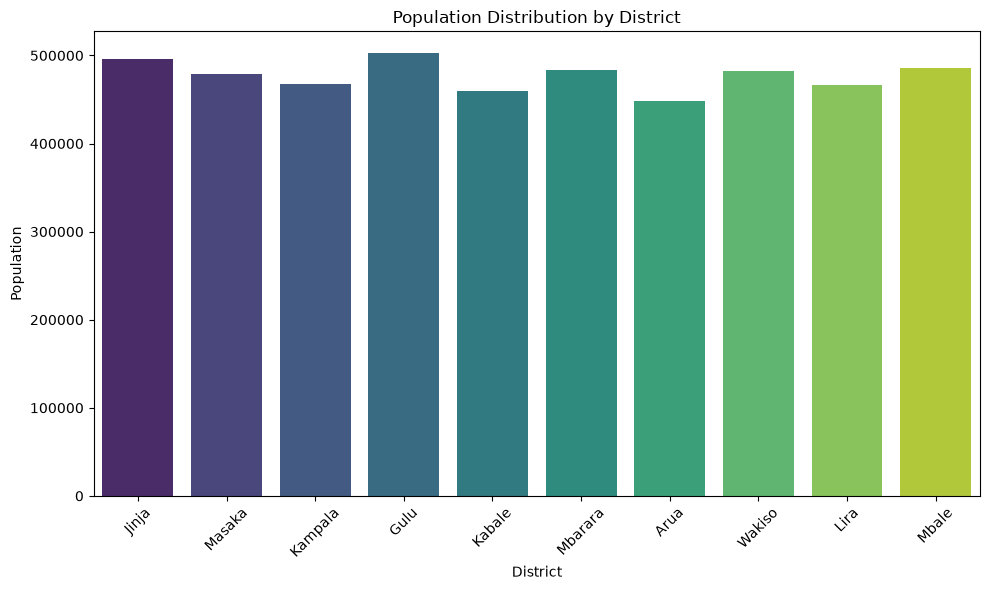

In [57]:
#A barplot for districts against population
plt.figure(figsize=(10, 6))
sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')
plt.title('Population Distribution by District')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
